
✅ New plot saved as 'echo_chamber_simple_colors.png' with clearer labels and colors.


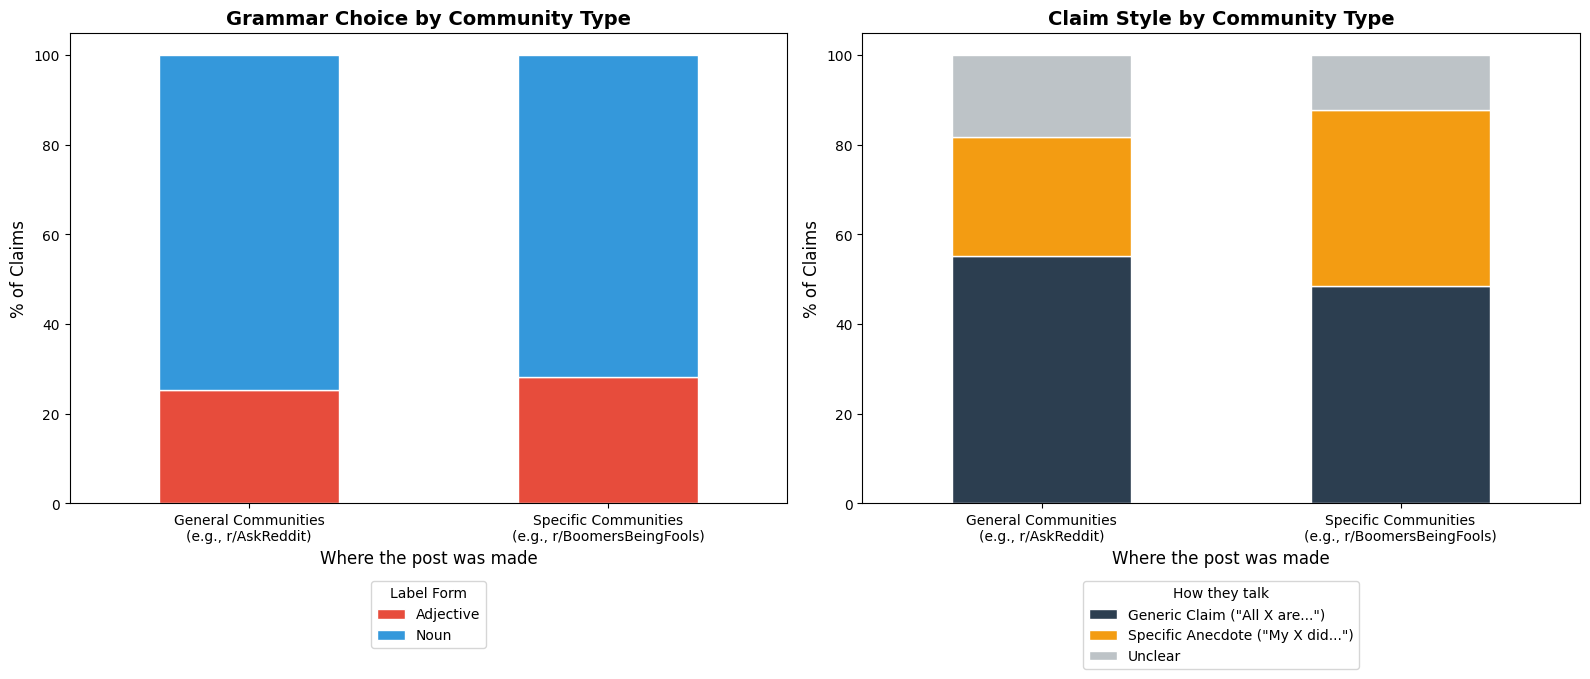

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df = pd.read_csv('/kaggle/input/notebooks/ianaaa/chat-gpt-annotating/generational_stereotypes_full_run.csv')

# 1. Prepare the data with clearer labels for the chart
plot_df = df.copy()
plot_df['subreddit_type'] = plot_df['subreddit_type'].map({
    'general': 'General Communities\n(e.g., r/AskReddit)', 
    'specific': 'Specific Communities\n(e.g., r/BoomersBeingFools)'
})

plot_df['generic'] = plot_df['generic'].map({
    'Generic': 'Generic Claim ("All X are...")',
    'Specific': 'Specific Anecdote ("My X did...")',
    'Unclear': 'Unclear'
})

# 2. ANALYSIS: Label Form
label_subset = plot_df[plot_df['label_form'].isin(['Noun', 'Adjective'])]
ct_label = pd.crosstab(label_subset['subreddit_type'], label_subset['label_form'])

# 3. ANALYSIS: Genericity
ct_gen = pd.crosstab(plot_df['subreddit_type'], plot_df['generic'])

# 4. VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot A: Label Form (Noun vs Adjective)
(ct_label.div(ct_label.sum(1), axis=0) * 100).plot(
    kind='bar', stacked=True, ax=ax1, color=['#e74c3c', '#3498db'], edgecolor='white'
)
ax1.set_title("Grammar Choice by Community Type", fontsize=14, fontweight='bold')
ax1.set_ylabel("% of Claims", fontsize=12)
ax1.set_xlabel("Where the post was made", fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(title="Label Form", loc='upper center', bbox_to_anchor=(0.5, -0.15))

# Plot B: Genericity (Generic vs Specific Anecdote)
(ct_gen.div(ct_gen.sum(1), axis=0) * 100).plot(
    kind='bar', stacked=True, ax=ax2, color=['#2c3e50', '#f39c12', '#bdc3c7'], edgecolor='white'
)
ax2.set_title("Claim Style by Community Type", fontsize=14, fontweight='bold')
ax2.set_ylabel("% of Claims", fontsize=12)
ax2.set_xlabel("Where the post was made", fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title="How they talk", loc='upper center', bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.savefig('echo_chamber_simple_colors.png')
print("\n✅ New plot saved as 'echo_chamber_simple_colors.png' with clearer labels and colors.")

In [1]:
import pandas as pd
from scipy.stats import chi2_contingency

df = pd.read_csv('/kaggle/input/notebooks/ianaaa/chat-gpt-annotating/generational_stereotypes_full_run.csv')

community_map = {
    'general': 'General Communities (e.g., r/AskReddit)',
    'specific': 'Specific Communities (e.g., r/BoomersBeingFools)'
}

claim_map = {
    'Generic': 'Generic Claim',
    'Specific': 'Specific Anecdote',
    'Unclear': 'Unclear'
}

df['community_labeled'] = df['subreddit_type'].map(community_map)
df['claim_labeled'] = df['generic'].map(claim_map)

def print_stat_block(data, col1, col2, title):
    print(f"\n{'='*60}")
    print(f" STATISTICAL REPORT: {title}")
    print(f"{'='*60}")
    
    # 1. Frequency Table (Counts)
    ct_counts = pd.crosstab(data[col1], data[col2])
    print("\n[1] RAW FREQUENCIES (N)")
    print(ct_counts)
    
    # 2. Percentage Table (Proportions)
    ct_perc = pd.crosstab(data[col1], data[col2], normalize='index') * 100
    print("\n[2] PERCENTAGES (%)")
    print(ct_perc.round(2).astype(str) + '%')
    
    # 3. Chi-Square Test
    chi2, p, dof, ex = chi2_contingency(ct_counts)
    print("\n[3] CHI-SQUARE TEST RESULTS")
    print(f" - Chi-Square Statistic: {chi2:.4f}")
    print(f" - p-value: {p:.4e}")
    print(f" - Degrees of Freedom: {dof}")
    
    if p < 0.05:
        print(" RESULT: Statistically Significant (p < 0.05)")
    else:
        print(" RESULT: Not Statistically Significant")

# --- Run Report A: Label Form (Noun vs Adjective) ---
label_subset = df[df['label_form'].isin(['Noun', 'Adjective'])]
print_stat_block(label_subset, 'community_labeled', 'label_form', "Community Type vs. Label Form")

# --- Run Report B: Claim Style (Generic vs Anecdote) ---
print_stat_block(df, 'community_labeled', 'claim_labeled', "Community Type vs. Claim Style")


 STATISTICAL REPORT: Community Type vs. Label Form

[1] RAW FREQUENCIES (N)
label_form                                        Adjective  Noun
community_labeled                                                
General Communities (e.g., r/AskReddit)                  91   269
Specific Communities (e.g., r/BoomersBeingFools)         89   227

[2] PERCENTAGES (%)
label_form                                       Adjective    Noun
community_labeled                                                 
General Communities (e.g., r/AskReddit)             25.28%  74.72%
Specific Communities (e.g., r/BoomersBeingFools)    28.16%  71.84%

[3] CHI-SQUARE TEST RESULTS
 - Chi-Square Statistic: 0.5777
 - p-value: 4.4723e-01
 - Degrees of Freedom: 1
 RESULT: Not Statistically Significant

 STATISTICAL REPORT: Community Type vs. Claim Style

[1] RAW FREQUENCIES (N)
claim_labeled                                     Generic Claim  \
community_labeled                                                 
General Co